In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt

plt.rcdefaults()
plt.rcParams.update({
    "text.usetex": True, # set to False if you don't have LaTeX installed
    "font.family": "serif",
})

In [7]:
noise_floor= 5e-3

# initial temperature density dataset

In [8]:
df = pd.read_csv('oscilliscope_data/NewMount180to200Improved.csv')
T = df.iloc[:,1].to_numpy() # temperature
I = df.iloc[:,2].to_numpy() # intensity

# normalize data so that fitting is easier
T_norm = (T - np.mean(T))/np.std(T)
I_norm = (I - np.min(I))/np.std(I)
#I_norm = (I - np.mean(I))/np.std(I)

In [9]:
def sinc2_linear(x, A, x0, w, m, b):
    # sinc function + linear component
    # A = amplitude, x0 = center, w = width parameter, m = slope, b = offset
    arg = (x - x0) / w
    return A * np.sinc(arg)**2 + m * x + b

# np.sinc(x) = sin(pi*x)/(pi*x), FWHM of sinc ≈ 1.21 * w
# So w ≈ FWHM / 1.21 ≈ 1 / 1.21 ≈ 0.83
p0 = [3, 0.3, 0.83, 0, 0]

popt, pcov = curve_fit(sinc2_linear, T_norm, I_norm, p0=p0)

A, x0, w, m, b = popt
print(f"Amplitude: {A:.4f}")
print(f"Center:    {x0:.4f}")
print(f"Width:     {w:.4f}")
print(f"Slope:     {m:.4f}")
print(f"Offset:    {b:.4f}")

# Generate fitted curve
T_norm_fit = np.linspace(T_norm.min(), T_norm.max(), 500)
I_norm_fit = sinc2_linear(T_norm_fit, *popt)

Amplitude: 2.6870
Center:    0.3755
Width:     0.9921
Slope:     0.2061
Offset:    0.2234


Peak location: T=192.4388
Peak width: dT=6.4427


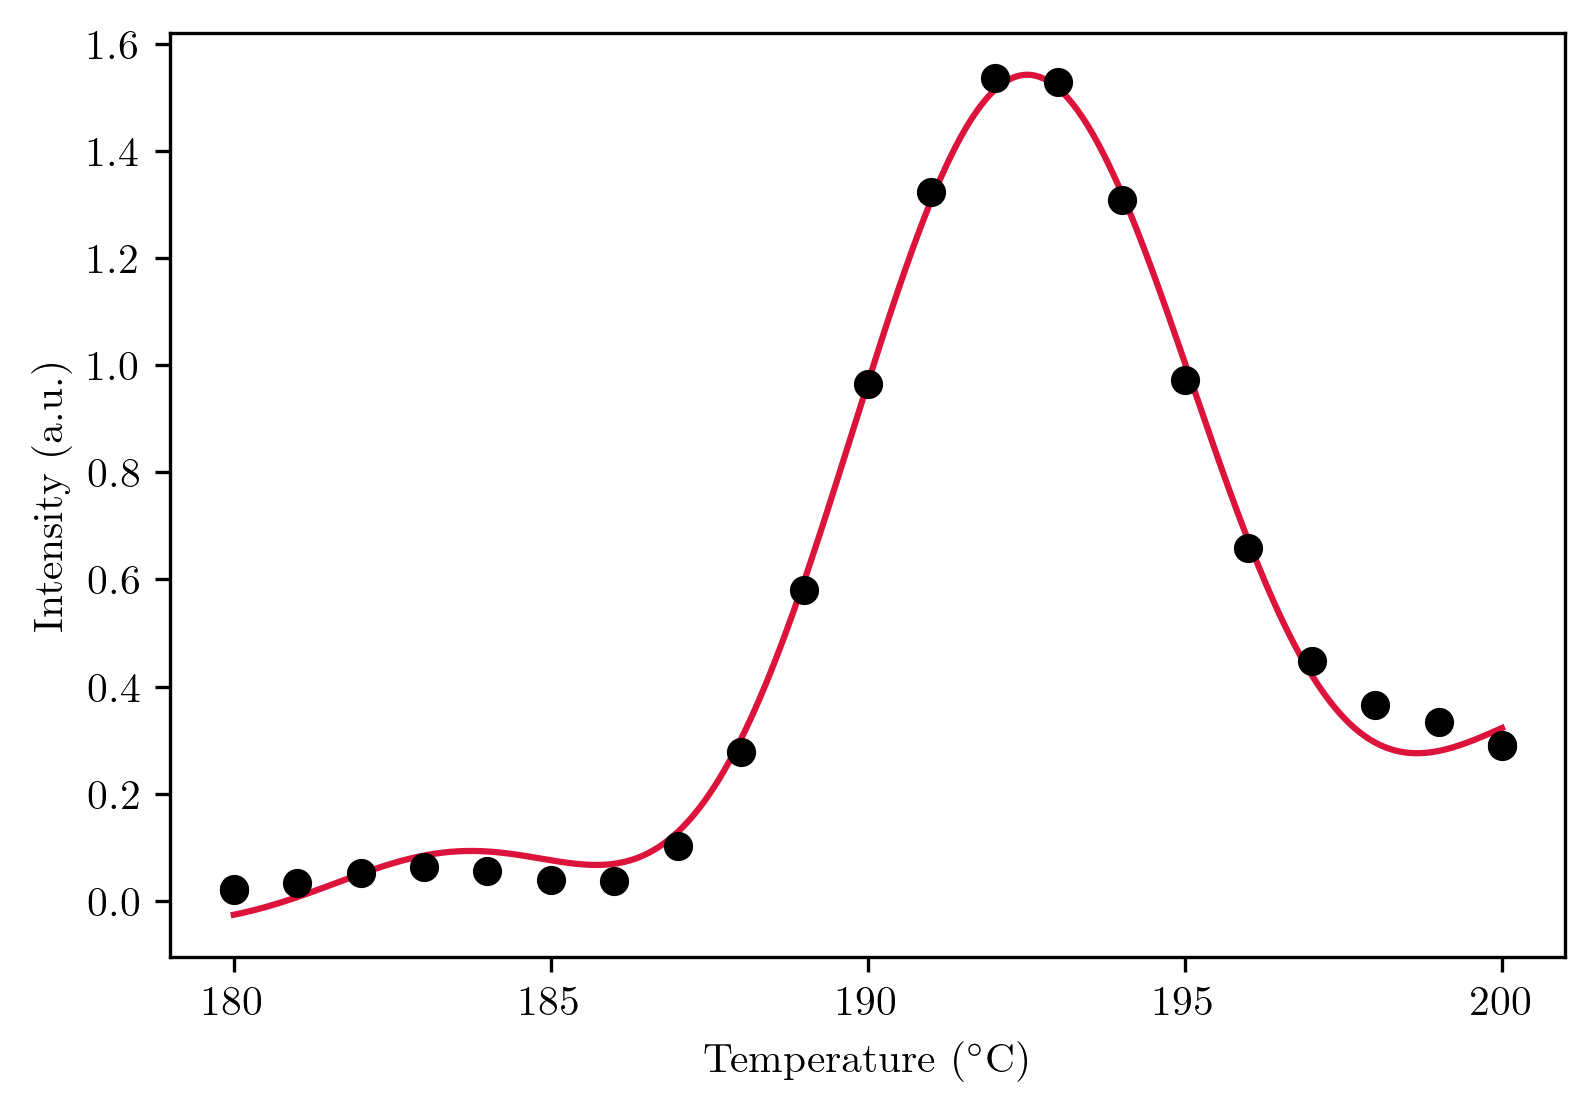

In [10]:
fig, ax = plt.subplots(figsize=(6,4), dpi=300)

#ax.set_yscale('log')

T_fit = np.std(T)*T_norm_fit + np.mean(T)
I_fit = np.std(I)*I_norm_fit + np.min(I)

T0 = np.std(T)*x0 + np.mean(T)
T_width = np.std(T)*w

ax.plot(T_fit, I_fit, color='crimson', zorder=1)
ax.scatter(T, I, color='k', zorder=2)

ax.set_xlabel('Temperature ($^{\\circ}$C)')
ax.set_xticks([180, 185, 190, 195, 200])
ax.set_ylabel('Intensity (a.u.)')

print(f'Peak location: T={T0:.4f}')
print(f'Peak width: dT={T_width:.4f}')

plt.show()

# Obtaining Confidence Intervals

In [11]:
from lmfit import Model, conf_interval, conf_interval2d
from lmfit.models import VoigtModel, GaussianModel

In [12]:


sinc2_linear_model = Model(sinc2_linear, prefix="sinc_")
broad = GaussianModel()


shg_model = sinc2_linear_model + broad

params = shg_model.make_params()

params['sinc_A'].set(value=3, min=0)
params['sinc_x0'].set(value=0.3)
params['sinc_w'].set(value=0.83)
params['sigma'].set(value=0.3)
params['sinc_m'].set(value=0)
params['sinc_b'].set(value=0)



# we will use this array  of points to evaluate the fit
T_norm_fit = np.linspace(T_norm.min(), T_norm.max(), 500)

# get the fit result
I_norm_fit_result = shg_model.fit(I_norm, params, x=T_norm)

#evaluate fit at fine sweep of x values
I_norm_fit_eval = I_norm_fit_result.eval(x=T_norm_fit)

# ci = conf_interval(I_norm_fit_result, I_norm_fit_result, sigmas=[1,2,3])

pred_ci = I_norm_fit_result.eval_uncertainty(x=T_norm_fit, sigma=3)

# print(ci)

# transform from normalized data to raw
T_fit = np.std(T)*T_norm_fit + np.mean(T)

# NOTE! DOUBLE CHECK THAT THESE MAKE SENSE
I_fit_eval = np.std(I)*I_norm_fit_eval + np.min(I)
# I_fit_eval = np.std(I)*I_norm_fit_eval + np.mean(I)

I_ci_up = np.std(I)*(I_norm_fit_eval + pred_ci) + np.min(I)
I_ci_down = np.std(I)*(I_norm_fit_eval - pred_ci) + np.min(I)

sinc_x0 = I_norm_fit_result.params['sinc_x0'].value
sinc_x0_stderr = I_norm_fit_result.params['sinc_x0'].stderr
sinc_w = I_norm_fit_result.params['sinc_w'].value
sinc_w_stderr = I_norm_fit_result.params['sinc_w'].stderr
w = I_norm_fit_result.params['sigma'].value

peak_center = np.std(T)*(sinc_x0) + np.mean(T)
peak_center_stderr = np.std(T)*(sinc_x0_stderr) 
sinc_width = np.std(T)*(sinc_w)
gauss_width = np.std(T)*(w)
peak_width = (sinc_width**2 + gauss_width**2)**(1/2)
# peak_width_stderr = np.std(T)*(sinc_w_stderr)

print(I_norm_fit_result.fit_report())

[[Model]]
    (Model(sinc2_linear, prefix='sinc_') + Model(gaussian))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 203
    # data points      = 23
    # variables        = 8
    chi-square         = 0.04437995
    reduced chi-square = 0.00295866
    Akaike info crit   = -127.760618
    Bayesian info crit = -118.676665
    R-squared          = 0.99807044
[[Variables]]
    sinc_A:     1.44418461 +/- 0.78891242 (54.63%) (init = 3)
    sinc_x0:    0.42837909 +/- 0.06234670 (14.55%) (init = 0.3)
    sinc_w:     1.10127205 +/- 0.05051594 (4.59%) (init = 0.83)
    sinc_m:     0.19716818 +/- 0.01708762 (8.67%) (init = 0)
    sinc_b:     0.22721142 +/- 0.01891787 (8.33%) (init = 0)
    amplitude:  0.99734073 +/- 0.77345750 (77.55%) (init = 1)
    center:     0.32642153 +/- 0.02467517 (7.56%) (init = 0)
    sigma:      0.29728919 +/- 0.05468220 (18.39%) (init = 0.3)
    fwhm:       0.70006253 +/- 0.12876673 (18.39%) == '2.3548200*sigma'
    height:     1.33836486 

c:\Users\diyan\anaconda3\envs\simulation\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


<span style="color:red"> Change parameter background noise 

Peak location: T=192.7820
Peak width: dT=7.4078


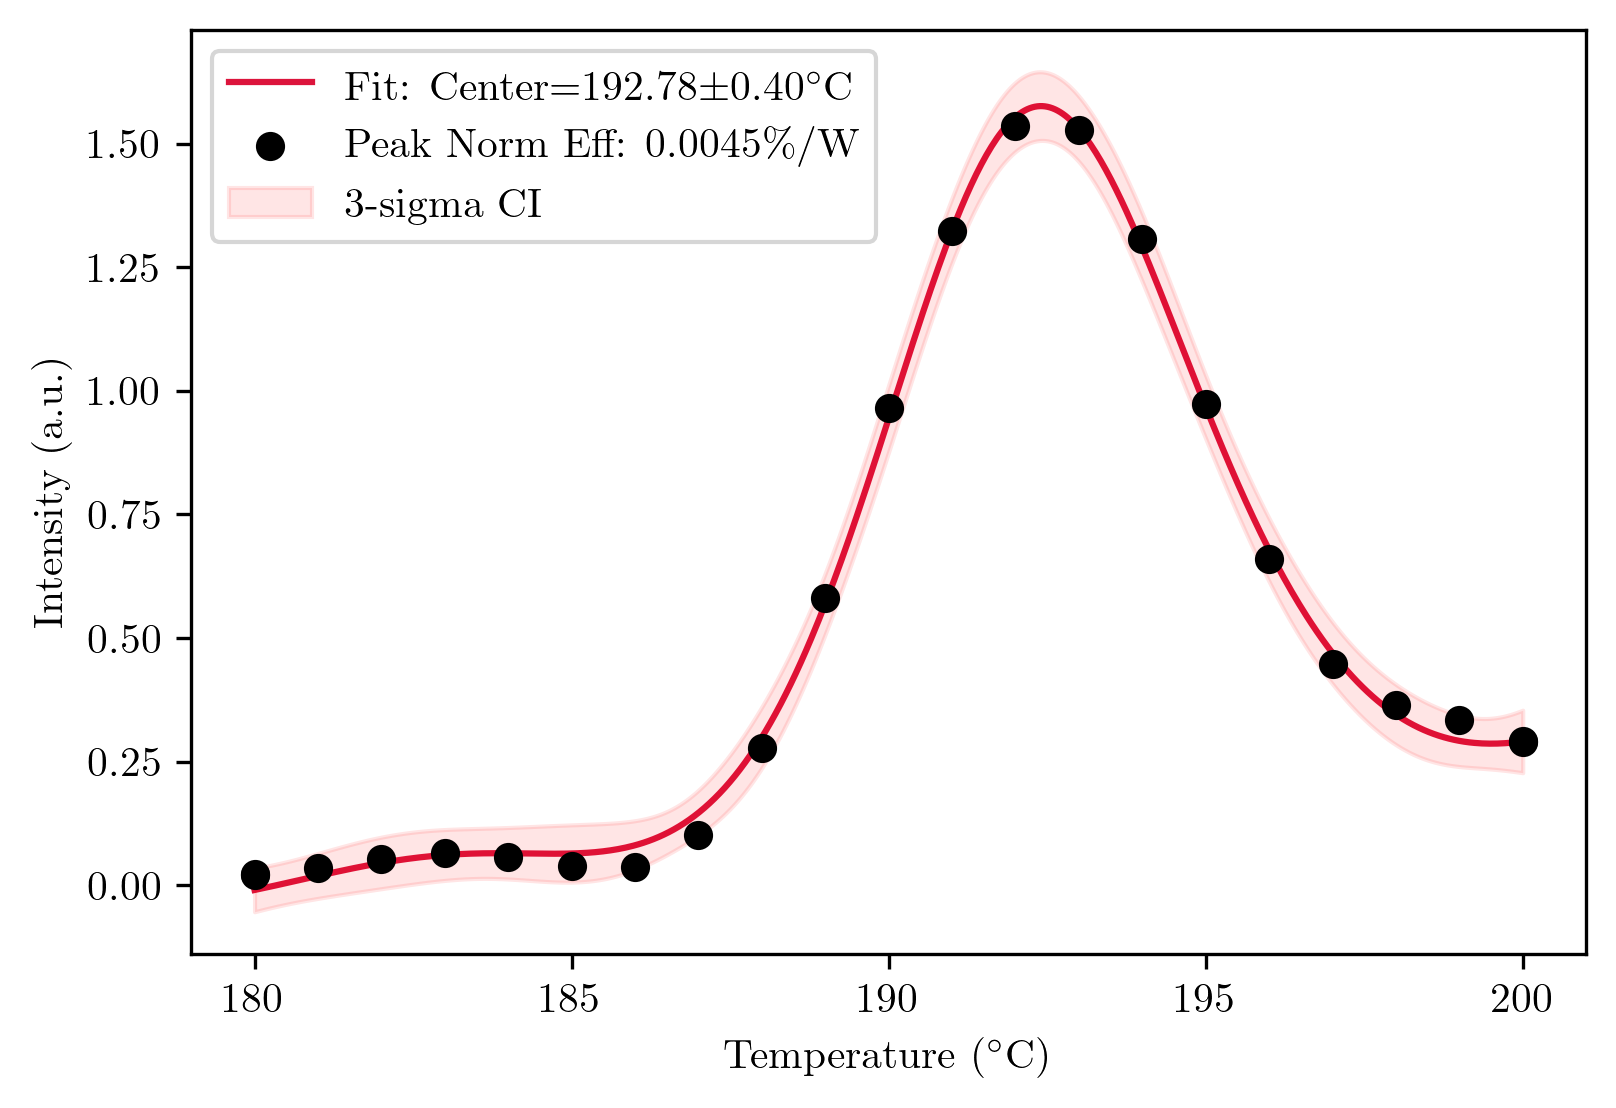

In [13]:
BACKGROUND_NOISE = 2e-3

label_text= f"Fit: Center={peak_center:.2f}±{peak_center_stderr:.2f}" + "$^{\\circ}$C"

fig, ax = plt.subplots(figsize=(6,4), dpi=300)
ax.plot(T_fit, I_fit_eval, color='crimson', zorder=1, 
                           label=label_text)
# plt.errorbar(T, I, yerr=BACKGROUND_NOISE, fmt = 'none', capsize=5, zorder=3)
ax.scatter(T, I, color='k', zorder=2, label = "Peak Norm Eff: 0.0045\\%/W")
plt.fill_between(T_fit, I_ci_down, I_ci_up, 
                 color='red', alpha=0.1, label='3-sigma CI')

ax.set_xlabel('Temperature ($^{\\circ}$C)')
ax.set_xticks([180, 185, 190, 195, 200])
ax.set_ylabel('Intensity (a.u.)')
plt.legend()

print(f'Peak location: T={peak_center:.4f}')
print(f'Peak width: dT={peak_width:.4f}')

In [93]:
import numpy as np
from scipy.signal import fftconvolve
from lmfit import Model

def convolved_sinc_gauss(x, A, x0, w, sigma, m, b):
    """
    x: independent variable
    amplitude: scaling factor
    center: peak location
    sinc_w: width of the sinc (null-to-null is 2/sinc_w in np.sinc)
    sigma: Gaussian standard deviation
    intercept: background/offset
    """

    # 1. Create a fine, uniform grid for the convolution to avoid artifacts
    # It must be wider than the data to prevent edge effects
    x_min, x_max = x.min() , x.max() 
    x_min, x_max = x.min() , x.max() 
    x_fine = np.linspace(x_min - 3.3*sigma, x_max + 1.6*sigma, 2048)
    dx = x_fine[1] - x_fine[0]
    
    # 2. Define the components on the fine grid, centered at 0
    # We center them at 0 for the convolution, then shift the result
    sinc_part = sinc2_linear(x_fine, A, x0, w, m, b)
    gauss_part = np.exp(-x_fine**2 / (2 * sigma**2))
    
    # 3. Perform the convolution
    # mode='same' keeps the output the same size as the input
    conv = fftconvolve(sinc_part, gauss_part, mode='same') * dx
    
    # 4. Normalize and shift
    # Shift the result so the peak is at 'center'
    # Interpolate the fine-grid convolution onto the actual 'x' values
    result = np.interp(x - x0, x_fine, conv)
    
    # 5. Scale and add offset
    return (A * (result / np.max(result))) +  m*result + b

# Create the lmfit Model
shg_model = Model(convolved_sinc_gauss)

In [106]:

params = shg_model.make_params()

params['A'].set(value=3, min=0)
params['x0'].set(value=0.3)
params['w'].set(value=0.83)
params['sigma'].set(value=0.5)
params['m'].set(value=0)
params['b'].set(value=0)



# we will use this array  of points to evaluate the fit
T_norm_fit = np.linspace(T_norm.min() , T_norm.max(), 2048)

# get the fit result
I_norm_fit_result = shg_model.fit(I_norm, params, x=T_norm)

#evaluate fit at fine sweep of x values
I_norm_fit_eval = I_norm_fit_result.eval(x=T_norm_fit)

# ci = conf_interval(I_norm_fit_result, I_norm_fit_result, sigmas=[1,2,3])

pred_ci = I_norm_fit_result.eval_uncertainty(x=T_norm_fit, sigma=3)

# print(ci)

# transform from normalized data to raw
T_fit = np.std(T)*T_norm_fit + np.mean(T)

# NOTE! DOUBLE CHECK THAT THESE MAKE SENSE
I_fit_eval = np.std(I)*I_norm_fit_eval + np.min(I)
# I_fit_eval = np.std(I)*I_norm_fit_eval + np.mean(I)

I_ci_up = np.std(I)*(I_norm_fit_eval + pred_ci) + np.min(I)
I_ci_down = np.std(I)*(I_norm_fit_eval - pred_ci) + np.min(I)

sinc_x0 = I_norm_fit_result.params['x0'].value
sinc_x0_stderr = I_norm_fit_result.params['x0'].stderr
sinc_w = I_norm_fit_result.params['w'].value
sinc_w_stderr = I_norm_fit_result.params['w'].stderr
# w = I_norm_fit_result.params['sigma'].value

peak_center = np.std(T)*(sinc_x0) + np.mean(T)
peak_center_stderr = np.std(T)*(sinc_x0_stderr) 
sinc_width = np.std(T)*(sinc_w)
gauss_width = np.std(T)*(w)
# peak_width = (sinc_width**2 + gauss_width**2)**(1/2)
# peak_width_stderr = np.std(T)*(sinc_w_stderr)
print(sinc_width)
# print(I_norm_fit_result.fit_report())

6.387633828182704


In [107]:
T_fine = np.linspace(T_norm.min(), T_norm.max(), 1000)
I_final = I_norm_fit_result.eval(x=T_fine)

# Helper to find FWHM
def find_fwhm(x, y):
    half_max = (y.max() + y.min()) / 2.0
    indices = np.where(y >= half_max)[0]
    return x[indices[-1]] - x[indices[0]]

total_width_norm = find_fwhm(T_fine, I_final)
total_width_raw = total_width_norm * np.std(T)

print(total_width_raw )

6.226226226226225


Peak location: T=191.0326
Peak width: dT=6.2262


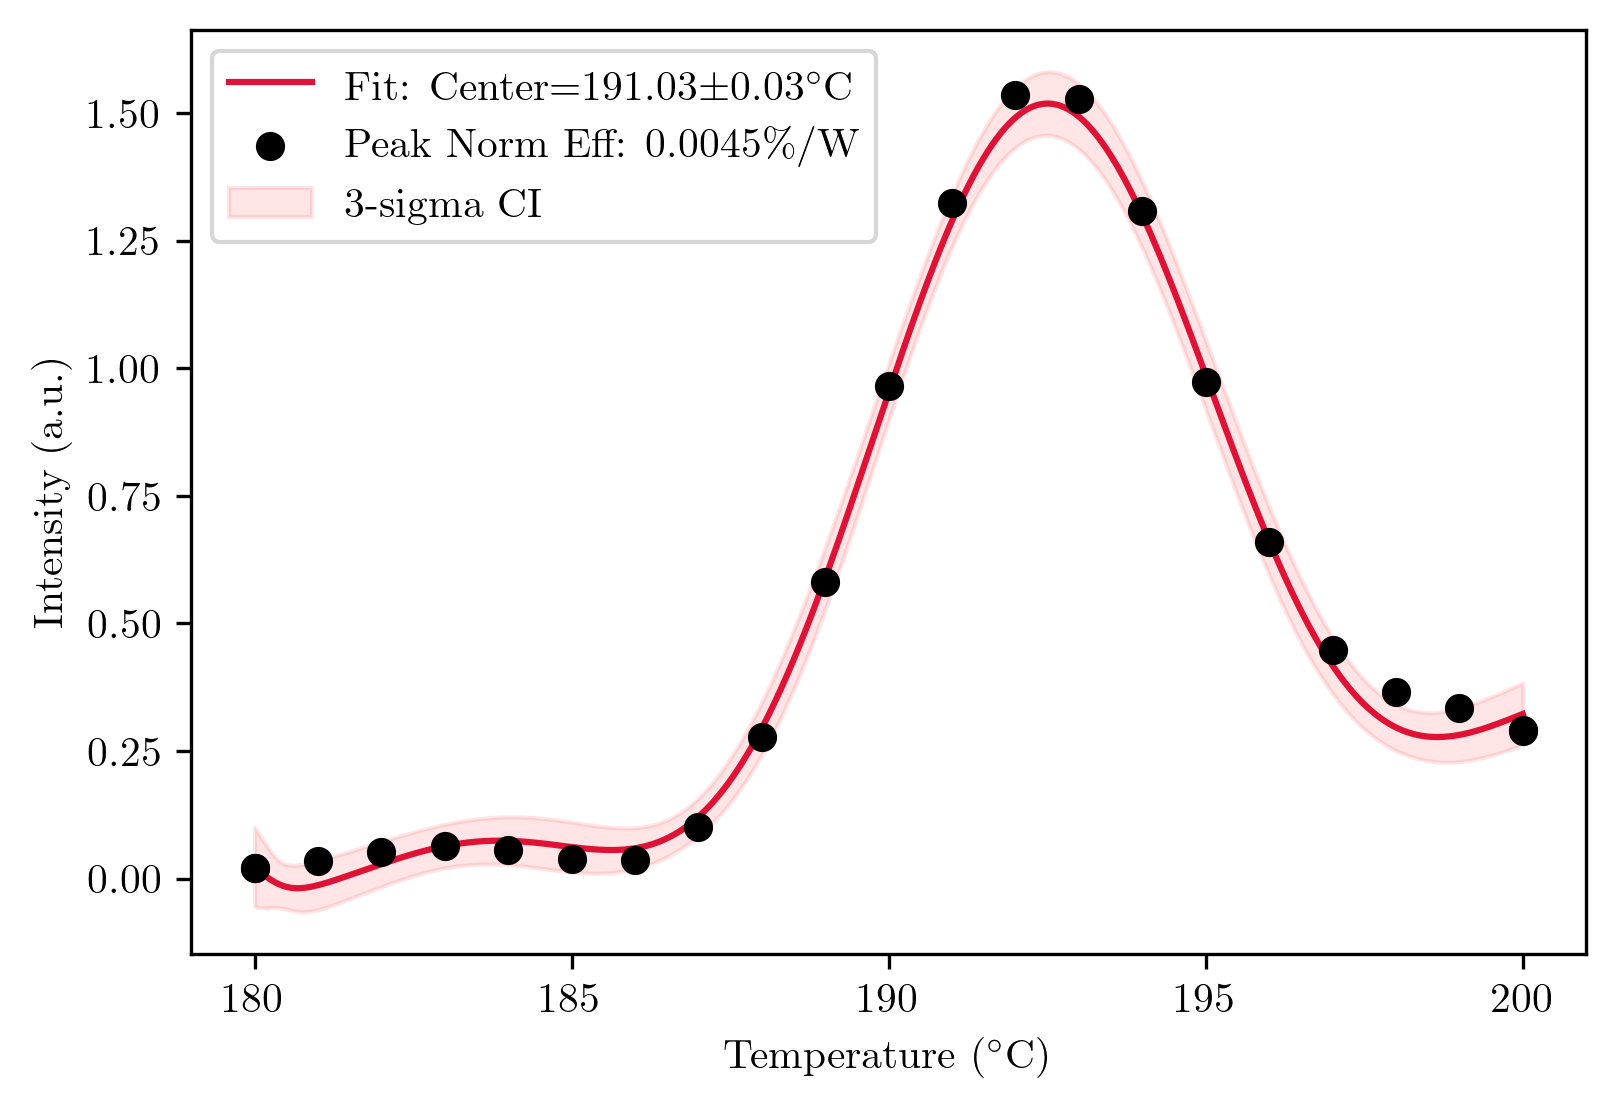

In [108]:

label_text= f"Fit: Center={peak_center:.2f}±{peak_center_stderr:.2f}" + "$^{\\circ}$C"

fig, ax = plt.subplots(figsize=(6,4), dpi=300)
ax.plot(T_fit, I_fit_eval, color='crimson', zorder=1, 
                           label=label_text)
# plt.errorbar(T, I, yerr=BACKGROUND_NOISE, fmt = 'none', capsize=5, zorder=3)
ax.scatter(T, I, color='k', zorder=2, label = "Peak Norm Eff: 0.0045\\%/W")
plt.fill_between(T_fit, I_ci_down, I_ci_up, 
                 color='red', alpha=0.1, label='3-sigma CI')

ax.set_xlabel('Temperature ($^{\\circ}$C)')
ax.set_xticks([180, 185, 190, 195, 200])
ax.set_ylabel('Intensity (a.u.)')
plt.legend()

print(f'Peak location: T={peak_center:.4f}')
print(f'Peak width: dT={total_width_raw:.4f}')

Lets look at the confidence intervals of each of the parameters of the model

This code is adapted from the example array of parameter confidence interval contour plots here: "https://lmfit.github.io/lmfit-py/confidence.html#confidence-chapter"

# NEXT TASK: NORMALIZE THE CI INFO 

ValueError: f(a) and f(b) must have different signs, but f(2.378961e+00)=3.168120e-01, f(2.478478e+00)=2.757412e-01 

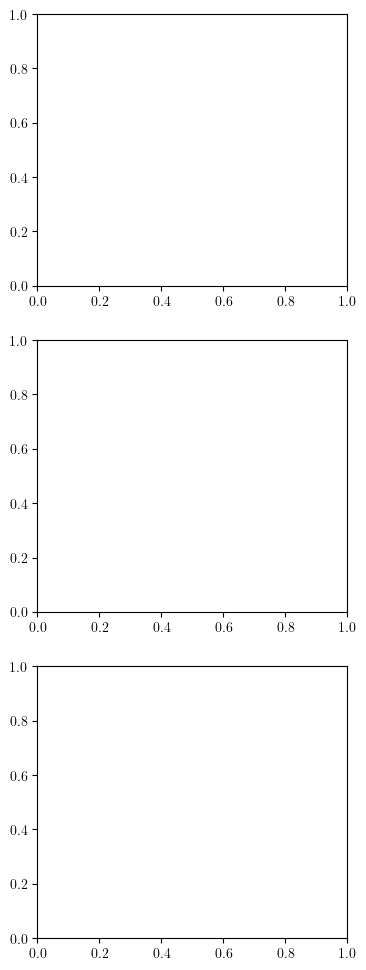

In [15]:
explicitly_calculate_sigma = True
nsamples = 80

aix, aiy = 0, 0
colors = ('#2030b0', '#b02030', '#207070')
sigma_levels = [1,2,3]
fig, axes = plt.subplots(3, 1, figsize=(4, 12))
ci = conf_interval(I_norm_fit_result, I_norm_fit_result, sigmas=sigma_levels)

map_info = {'sinc_A': [np.min(I), np.std(I)], 
            'sinc_x0': [np.mean(T), np.std(T)], 
            'sinc_w': [0, np.std(T)]}

for pairs in (('sinc_A', 'sinc_x0'), ('sinc_x0', 'sinc_w'),
              ('sinc_w', 'sinc_A')):

    xpar, ypar = pairs
    
    if explicitly_calculate_sigma:
        print(f"Generating chi-square map for {pairs}")
        c_x, c_y, chi2_mat = conf_interval2d(I_norm_fit_result, I_norm_fit_result, xpar, ypar,
                                             nsamples, nsamples, nsigma=3,
                                             chi2_out=True)
        # explicitly calculate sigma matrix: sigma increases chi_square
        # from  chi_square_best
        # to    chi_square + sigma**2 * reduced_chi_square
        # so:   sigma = sqrt((chi2-chi2_best)/ reduced_chi_square)
        chi2_min = chi2_mat.min()
        sigma_mat = np.sqrt((chi2_mat-chi2_min)/I_norm_fit_result.redchi)
    else:
        print(f"Generating sigma map for {pairs}")
        # or, you could just calculate the matrix of probabilities as:
        c_x, c_y, sigma_mat = conf_interval2d(I_norm_fit_result, I_norm_fit_result, xpar, ypar,
                                              nsamples, nsamples, nsigma=3)

    

    # 1. Grab scaling factors for the current pair
    x_mean, x_std = map_info[xpar]
    y_mean, y_std = map_info[ypar]

    # 2. Reverse the transformation for the grid coordinates
    c_x_unnorm = (c_x * x_std) + x_mean
    c_y_unnorm = (c_y * y_std) + y_mean

    best_x = I_norm_fit_result.params[xpar].value
    best_y = I_norm_fit_result.params[ypar].value

    best_x_unnorm = (best_x * x_std) + x_mean
    best_y_unnorm = (best_y * y_std) + y_mean


    # aix += 1
    ax = axes[aiy]
    aiy += 1
    # if aix == 2:
    #     aix = 0
    #     aiy += 1
   

    cnt = ax.contour(c_x_unnorm, c_y_unnorm, sigma_mat, levels=sigma_levels, colors=colors,
                     linestyles='-')
    ax.clabel(cnt, inline=True, fmt=r"$\sigma=%.0f$", fontsize=13)
    ax.plot(best_x_unnorm, best_y_unnorm, 'ro', markersize=8, label=f'{best_x_unnorm:.2f}, {best_y_unnorm:.2f}') 

    
    ax.set_title(f"Confidence Interval of {xpar} and {ypar}")

    ax.set_xlabel(xpar)
    ax.set_ylabel(ypar)
    ax.grid(True, color='#d0d0d0')
    ax.legend()
plt.show()

# power vs temp

[np.float64(8.63713321e-10), np.float64(2.123182084e-09), np.float64(3.997021284e-09), np.float64(4.470794496000001e-09), np.float64(1.4364858009999997e-09), np.float64(1.56700324e-08), np.float64(1.40625e-07), np.float64(3.160800841e-07), np.float64(7.108850596000001e-07), np.float64(1.08722329e-06), np.float64(1.2312121599999998e-06), np.float64(9.501375625000001e-07), np.float64(5.281364928999999e-07), np.float64(1.945956769e-07), np.float64(3.92000401e-08), np.float64(6.868928640999999e-09), np.float64(5.7729604000000004e-09), np.float64(7.793711524e-09), np.float64(7.562389443999998e-09)]


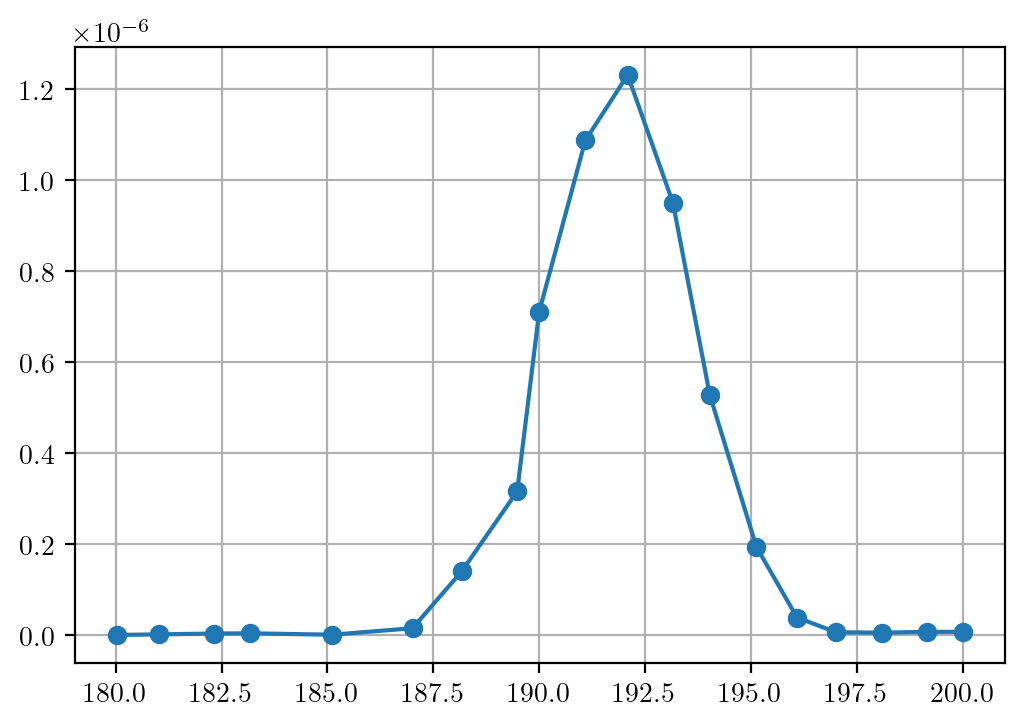

In [74]:
R = 1e6  # 1 MΩ scope input impedance

power_watts = [(v**2)/R for v in I]
print(power_watts)
#plot for power in watts
fig, ax = plt.subplots(figsize=(6,4), dpi=200)
plt.plot(T, power_watts, marker='o')
# plt.xlabel("Temperature")
# plt.ylabel("Power (W)")
# plt.title("Power vs Temperature (1 MΩ Load)")
plt.grid(True)
# plt.xlim(180, 200)
# plt.xticks(range(180, 201, 1), fontsize=8)
plt.show()
